In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import plotly.express as px

In [3]:
data = pd.read_csv("InsuranceData.csv")

In [4]:
data.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1340 non-null   int64  
 1   PatientID      1340 non-null   int64  
 2   age            1335 non-null   float64
 3   gender         1340 non-null   object 
 4   bmi            1340 non-null   float64
 5   bloodpressure  1340 non-null   int64  
 6   diabetic       1340 non-null   object 
 7   children       1340 non-null   int64  
 8   smoker         1340 non-null   object 
 9   region         1337 non-null   object 
 10  claim          1340 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 115.3+ KB


In [6]:
data.describe()

,index,PatientID,age,bmi,bloodpressure,children,claim
count,1340.000000,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,669.500000,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,0.000000,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,334.750000,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,669.500000,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1004.250000,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1339.000000,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [7]:
# Distribution of Insurance by Age

In [8]:
agg = data.groupby('age').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='age', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'age': 'Age',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Age with Hover Info')

fig.show()

In [9]:
# Distribution of Insurance Claims by Gender

In [10]:
agg = data.groupby('gender').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='gender', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'gender': 'Gender',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Gender with Hover Info')

fig.show()

In [11]:
# Distribution of Insurance Claims by BMI

In [12]:
agg = data.groupby('bmi').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='bmi', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'bmi': 'BMI',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by BMI with Hover Info')

fig.show()

In [13]:
new_data = data.copy()

# Example: Creating BMI clusters
bins = [0, 18.5, 25, 30, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

# Assuming 'data' is your DataFrame with 'bmi' and 'claim' columns
new_data['bmi_cluster'] = pd.cut(data['bmi'], bins=bins, labels=labels)

# Group by bmi_cluster and aggregate sum of claims
agg = new_data.groupby('bmi_cluster', observed=True).agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size')
).reset_index()

print(agg)  # Optional: check the grouped data

# Plot sum of claims by BMI cluster
fig = px.bar(agg, x='bmi_cluster', y='sum_claim', text='sum_claim',
             title='Sum of Insurance Claims by BMI Cluster',
             labels={'bmi_cluster': 'BMI Category', 'sum_claim': 'Sum of Claims'})

fig.show()

   bmi_cluster    sum_claim     avg_claim  count
0  Underweight    181810.05   8657.621429     21
1       Normal   2360114.18  10396.978767    227
2   Overweight   4336733.30  11034.944784    393
3        Obese  10880021.63  15565.123934    699


In [14]:
# Distribution of Insurance Claims by Bloodpressure

In [15]:
agg = data.groupby('bloodpressure').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='bloodpressure', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'bloodpressure': 'Bloodpressure',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Bloodpressure with Hover Info')

fig.show()

In [16]:
new_data['bp_bin'] = pd.cut(data['bloodpressure'], bins=5)

agg = new_data.groupby('bp_bin').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim=('claim', 'max')
).reset_index()

agg['bp_bin'] = agg['bp_bin'].astype(str)  # Convert intervals to strings for plotting

fig = px.bar(agg, x='bp_bin', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False
             },
             labels={'sum_claim': 'Sum of Claims',
                     'bp_bin': 'Bloodpressure Range',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Bloodpressure Range with Hover Info')

fig.show()

In [17]:
data.head()

,index,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [18]:
# Distribution of Insurance Claims by Diabetic

In [19]:
agg = data.groupby('diabetic').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='diabetic', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'diabetic': 'Diabetic or Not',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Diabetes with Hover Info')

fig.show()

In [20]:
# Distribution of Insurance Claims by Number of Children

In [21]:
agg = data.groupby('children').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='children', y='sum_claim', text=agg['sum_claim'].round(2),
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'children': 'Children',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Number of Children with Hover Info')

fig.show()

In [22]:
# Distribution of Insurance Claims by Smoker

In [23]:
agg = data.groupby('smoker').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='smoker', y='sum_claim', text='sum_claim',
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'diabetic': 'Smoker or Not',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Smoking Habits with Hover Info')

fig.show()

In [24]:
#  Distribution of Insurance Claims by Region

In [25]:
agg = data.groupby('region').agg(
    sum_claim=('claim', 'sum'),
    avg_claim=('claim', 'mean'),
    count=('claim', 'size'),
    max_claim = ('claim', 'max')
).reset_index()

fig = px.bar(agg, x='region', y='sum_claim', text=agg['sum_claim'].round(2),
             hover_data={
                 'avg_claim': ':.2f',
                 'count': True,
                 'max_claim': True,
                 'sum_claim': False  # Hiding sum because already displayed on label
             },
             labels={'sum_claim': 'Sum of Claims',
                     'region': 'Region',
                     'avg_claim': 'Average Claim',
                     'max_claim': 'Max Claim',
                     'count': 'Number of Entries'},
             title='Sum of Claims by Region with Hover Info')

fig.show()


In [26]:
#  Violin plot showing the distribution of insurance claims by age

In [27]:
fig = px.violin(data, y="claim", x="age", box=True, points='all',hover_data=data.columns)
fig.show()


In [28]:
fig = px.scatter_3d(data, x='age', y='bmi', z='claim', color='smoker',
                    title='3D Scatter: Age, BMI, and Claim by Smoker',
                    labels={'age':'Age', 'bmi':'BMI', 'claim':'Claim Amount'})
fig.show()

In [29]:
import plotly.graph_objects as go

In [30]:
# the trends of insurance claims over time

In [31]:
age_group = data.groupby('age')['claim'].sum()
fig = go.Figure(data=go.Scatter(x=age_group.index, y=age_group, mode='lines+markers'))
fig.update_layout(title='Sum of Claims by Age', xaxis_title='Age', yaxis_title='Sum of Claim')
fig.show()

In [32]:
age_group = data.groupby('age')['claim'].mean()
fig = go.Figure(data=go.Scatter(x=age_group.index, y=age_group, mode='lines+markers'))
fig.update_layout(title='Average Claims by Age', xaxis_title='Age', yaxis_title='Average Claim')
fig.show()

In [33]:
#correlation matrix
# Correlation matrix on numeric columns only
corr = data.select_dtypes(include='number').corr()

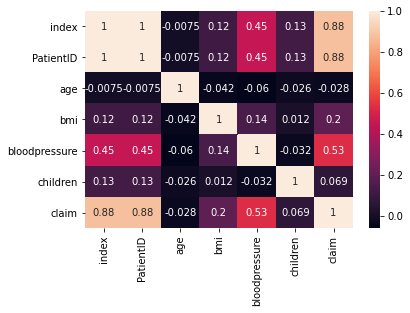

In [34]:
#heatmap of the correlation matrix
sns.heatmap(corr, annot=True)
plt.show()

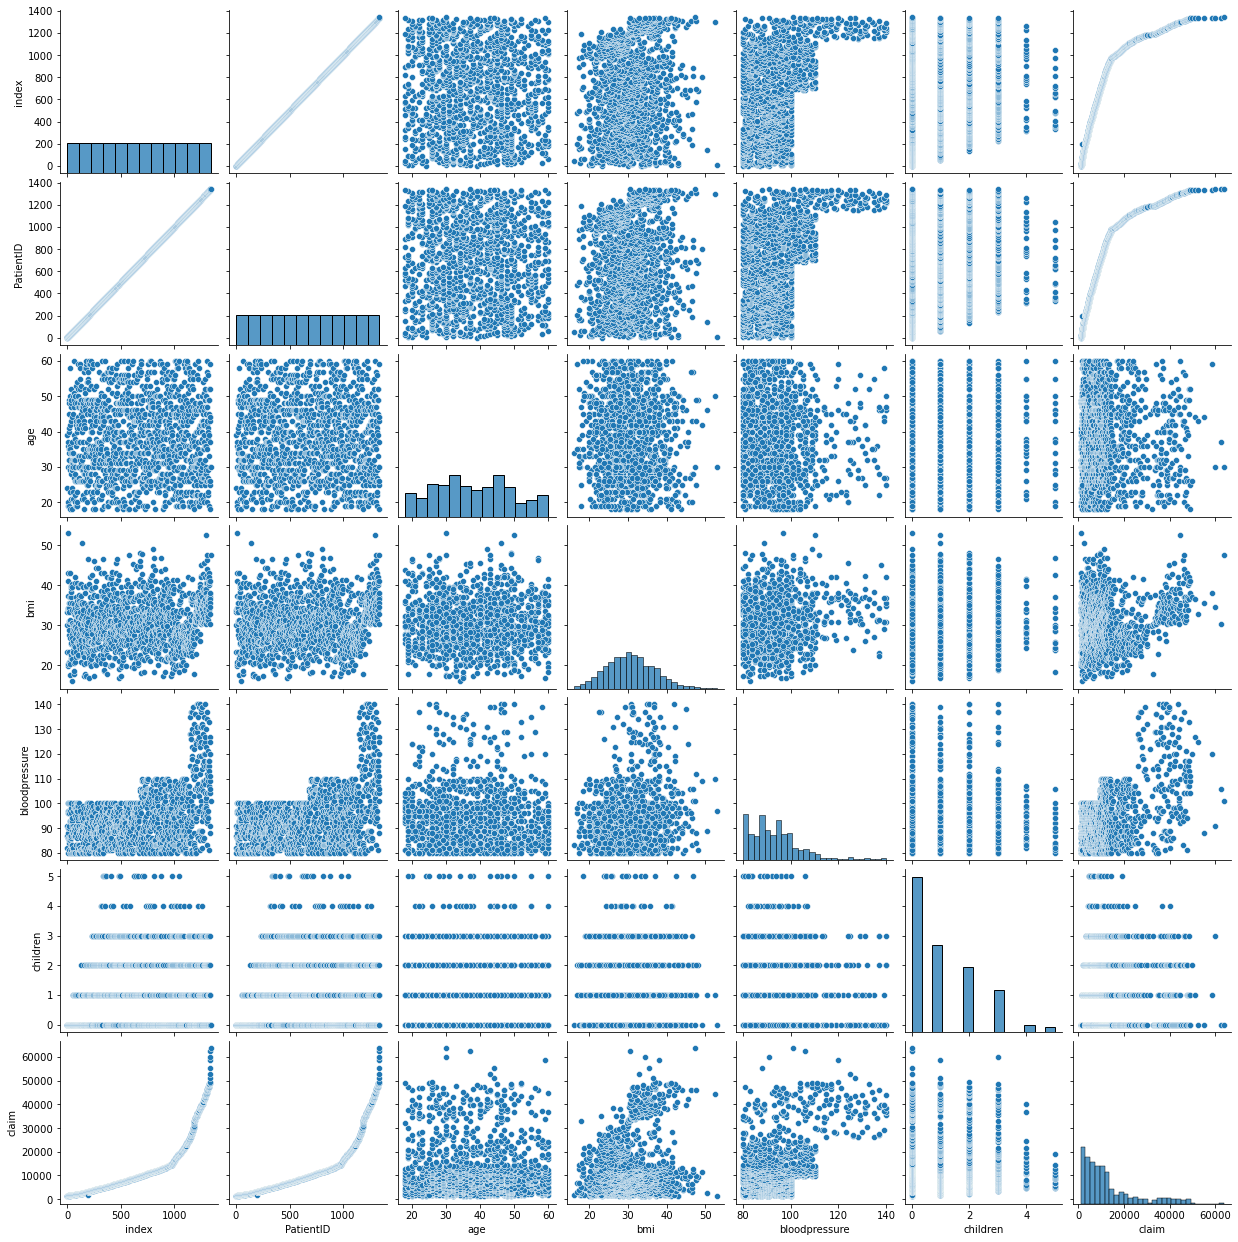

In [35]:
#pairplot function to generate scatter plots for the variables
sns.pairplot(data)
plt.show()

In [36]:
import numpy as np
from sklearn.impute import SimpleImputer  
from sklearn.preprocessing import StandardScaler  #numerical
from scipy import stats

In [37]:
def advanced_preprocess_numeric_columns(df, method='median'):
    # copy of the DataFrame to avoid modifying the original data
    df = df.copy()
    
    # Get a list of all numeric columns
    numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
    
    # Loop through each numeric column
    for col in numeric_columns:
        # Check if the column has missing values or outliers
        if df[col].isnull().any() or df[col].between(df[col].quantile(.01), df[col].quantile(.99)).all():
            # Fill missing values using SimpleImputer
            imputer = SimpleImputer(strategy=method)
            df[col] = imputer.fit_transform(df[col].values.reshape(-1, 1))

            # Scale the data using StandardScaler
            scaler = StandardScaler()
            df[col] = scaler.fit_transform(df[col].values.reshape(-1, 1))

            # Remove outliers using the Z-score
            z_scores = stats.zscore(df[col])
            df = df[np.abs(z_scores) < 3]
            
    print("Advanced preprocessing steps completed for columns that needed it: filled missing values, scaled data, and removed outliers.")
    return df

In [38]:
modified_df = pd.DataFrame(advanced_preprocess_numeric_columns(data, method='median'))

Advanced preprocessing steps completed for columns that needed it: filled missing values, scaled data, and removed outliers.


In [39]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

def advanced_preprocess_categorical_columns(df, encoding='onehot', ordinal_columns=None, rare_threshold=10, unknown_categories='Other'):
    """Takes a Pandas DataFrame and performs advanced preprocessing on all categorical columns.
    
    Fills missing values with the mode, removes rare categories, and encodes the data using one-hot encoding or ordinal encoding.
    
    Args:
        df: Pandas DataFrame
        encoding: encoding method to use ('onehot' or 'ordinal')
        ordinal_columns: dictionary of ordinal columns and their corresponding categories (e.g., {'column_name': ['low', 'medium', 'high']})
        rare_threshold: threshold for removing rare categories (default is 10)
        unknown_categories: label for unknown categories (default is 'Other')
        
    Returns:
        modified DataFrame
    """
    # Make a copy of the DataFrame to avoid modifying the original data
    df = df.copy()
    
    # Get a list of all categorical columns
    categorical_columns = df.select_dtypes(include=['object']).columns
    
    # Fill missing values with the mode
    for col in categorical_columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
    # Remove rare categories
    for col in categorical_columns:
        # Get the counts of each category
        counts = df[col].value_counts()
        
        # Remove categories with less than rare_threshold occurrences
        df[col] = df[col].apply(lambda x: x if counts[x] >= rare_threshold else unknown_categories)
        
    if encoding == 'onehot':
        # Encode the data using one-hot encoding
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
        
    elif encoding == 'ordinal':
        # Check if ordinal_columns is provided
        if ordinal_columns is None:
            raise ValueError("ordinal_columns must be provided when using ordinal encoding.")
            
        # Encode the data using ordinal encoding
        for col, categories in ordinal_columns.items():
            df[col] = df[col].astype('category', categories=categories, ordered=True)
            df[col] = df[col].cat.codes
            
    else:
        raise ValueError("Invalid encoding method. Must be 'onehot' or 'ordinal'.")
        
    print("Advanced preprocessing steps completed: filled missing values, removed rare categories, and encoded data.")
    return df

# Create a new dataframe to store the preprocessed data
preprocessed_df = pd.DataFrame()

# Preprocess the data and store it in the new dataframe
preprocessed_df = advanced_preprocess_categorical_columns(modified_df)

Advanced preprocessing steps completed: filled missing values, removed rare categories, and encoded data.


In [40]:
preprocessed_df

,index,PatientID,age,bmi,bloodpressure,children,claim,gender_male,diabetic_Yes,smoker_Yes,region_northwest,region_southeast,region_southwest
0,0,1,0.083195,23.2,91,-0.907376,1121.87,True,True,False,False,True,False
1,1,2,-1.270835,30.1,87,-0.907376,1131.51,True,False,False,False,True,False
2,2,3,-0.007073,33.3,82,-0.907376,1135.94,True,True,False,False,True,False
3,3,4,-0.007073,33.7,80,-0.907376,1136.40,True,False,False,True,False,False
4,4,5,-0.007073,34.1,100,-0.907376,1137.01,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,1335,1336,0.534539,35.5,88,-0.907376,55135.40,False,True,True,True,False,False
1336,1336,1337,1.888569,38.1,120,-0.077421,58571.07,False,False,True,False,False,False
1337,1337,1338,-0.729223,34.5,91,1.582489,60021.40,True,True,True,True,False,False
1338,1338,1339,-0.097342,30.4,106,-0.907376,62592.87,True,False,True,False,True,False


In [41]:
preprocessed_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1322 entries, 0 to 1339
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             1322 non-null   int64  
 1   PatientID         1322 non-null   int64  
 2   age               1322 non-null   float64
 3   bmi               1322 non-null   float64
 4   bloodpressure     1322 non-null   int64  
 5   children          1322 non-null   float64
 6   claim             1322 non-null   float64
 7   gender_male       1322 non-null   bool   
 8   diabetic_Yes      1322 non-null   bool   
 9   smoker_Yes        1322 non-null   bool   
 10  region_northwest  1322 non-null   bool   
 11  region_southeast  1322 non-null   bool   
 12  region_southwest  1322 non-null   bool   
dtypes: bool(6), float64(4), int64(3)
memory usage: 90.4 KB


In [42]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Drop target column
X = preprocessed_df.drop(columns=["claim"])

# Keep only numeric columns
X_numeric = X.select_dtypes(include=['number'])

# Optionally drop rows with missing values or fill them
X_numeric = X_numeric.dropna()

# Calculate VIF
vif = pd.DataFrame()
vif["features"] = X_numeric.columns
vif["VIF"] = [variance_inflation_factor(X_numeric.values, i) for i in range(X_numeric.shape[1])]

print(vif)

        features           VIF
0          index  5.439082e+07
1      PatientID  5.452124e+07
2            age  1.005969e+00
3            bmi  1.025300e+00
4  bloodpressure  1.283274e+00
5       children  1.031813e+00


In [44]:
# the VIF values for all the independent variables are less than 10 which is considered acceptable and indicates that there is no multicollinearity among the independent variables

In [45]:
# Split the dataset into training and testing sets

In [46]:
preprocessed_df = preprocessed_df.drop(columns=['index','PatientID'])

In [47]:
from sklearn.model_selection import train_test_split

# Assign the independent variables (X) and dependent variable (y)
X = preprocessed_df.drop('claim' , axis=1)
y = preprocessed_df['claim']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
print(len(X_train))
print(len(y_train))

1057
1057


In [49]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)


LinearRegression()

In [84]:
pip install --upgrade pandas statsmodels

Note: you may need to restart the kernel to use updated packages.


In [85]:
import statsmodels.api as sm

ImportError: cannot import name 'PD_LT_2' from 'statsmodels.compat.pandas' (C:\Users\91882\anaconda3\lib\site-packages\statsmodels\compat\pandas.py)

In [59]:
# Check normality assumption

In [60]:
residuals = y_train - lin_reg.predict(X_train)
fig = sm.graphics.qqplot(residuals, dist=stats.norm, line='45', fit=True)
plt.show()

NameError: name 'sm' is not defined

In [56]:
# Check homoscedasticity assumption

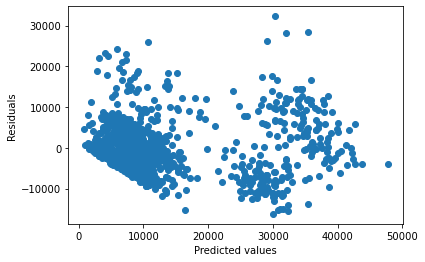

In [57]:
plt.scatter(lin_reg.predict(X_train), residuals)
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.show()

In [61]:
# Check independence assumption

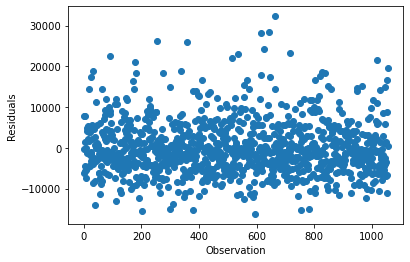

In [62]:
plt.scatter(range(len(residuals)), residuals)
plt.xlabel('Observation')
plt.ylabel('Residuals')
plt.show()

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_pred = lin_reg.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)

y_pred_lin = lin_reg.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred_lin)
mse_test = mean_squared_error(y_test, y_pred_lin)
r2_test = r2_score(y_test, y_pred_lin)

print("Mean Absolute Error (Training): ", mae_train)
print("Mean Squared Error (Training): ", mse_train)
print("Mean Absolute Error (Testing): ", mae_test)
print("Mean Squared Error (Testing): ", mse_test)
print("R2 Score (Testing): ", r2_test)

Mean Absolute Error (Training):  4935.098314788079
Mean Squared Error (Training):  43353416.361235976
Mean Absolute Error (Testing):  4941.319748714536
Mean Squared Error (Testing):  43363792.54561998
R2 Score (Testing):  0.6892020651494011


In [64]:
# The model appears to perform similarly on the training and testing sets, with the MAE and MSE being very close for both sets.

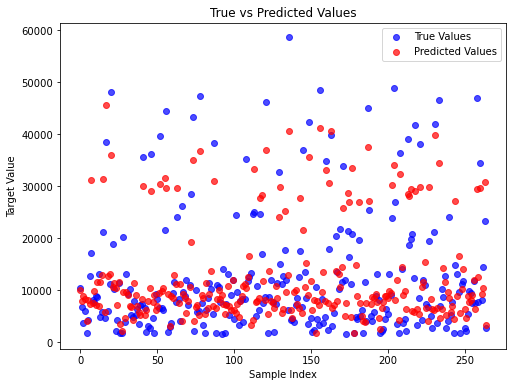

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='True Values', alpha=0.7)
plt.scatter(range(len(y_test_pred)), y_test_pred, color='red', label='Predicted Values', alpha=0.7)

plt.xlabel("Sample Index")
plt.ylabel("Target Value")
plt.title("True vs Predicted Values")
plt.legend()
plt.show()

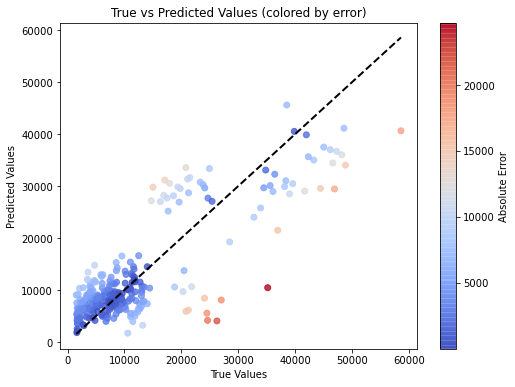

In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate absolute error
errors = np.abs(y_test - y_test_pred)

# Create scatter plot with color mapped to error magnitude
plt.figure(figsize=(8, 6))
scatter = plt.scatter(y_test, y_test_pred, c=errors, cmap='coolwarm', alpha=0.8)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (colored by error)")
plt.colorbar(scatter, label="Absolute Error")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # perfect prediction line
plt.show()

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score

In [69]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train, y_train)
y_pred_dt = dt_reg.predict(X_test)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_r2 = r2_score(y_test, y_pred_dt)
print("Decision Tree Model")
print("Mean Squared Error (Testing): ", dt_mse)
print("R2 Score (Testing): ", dt_r2)

Decision Tree Model
Mean Squared Error (Testing):  51985071.920680754
R2 Score (Testing):  0.6274114405696882


In [70]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Mean Squared Error (Testing): ", mean_squared_error(y_test, y_pred))
print("R2 Score (Testing): ", r2_score(y_test, y_pred))

Mean Squared Error (Testing):  29498073.161653757
R2 Score (Testing):  0.7885807563748276


In [71]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [72]:
# Create an instance of the Random Forest model
rf_reg = RandomForestRegressor()

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred_rf)
print("Random Forest model")
print("Mean Squared Error (Testing): ", mse)
r2 = r2_score(y_test, y_pred_rf)
print("R2 Score (Testing): ", r2)

Random Forest model
Mean Squared Error (Testing):  28457527.127745252
R2 Score (Testing):  0.7960385809669805


In [73]:
# Create an instance of the Gradient Boosting model
gb_reg = GradientBoostingRegressor()

gb_reg.fit(X_train, y_train)

y_pred_gb = gb_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred_gb)
print("Gradient Boosting model")
print("Mean Squared Error (Testing): ", mse)

r2 = r2_score(y_test, y_pred_gb)
print("R2 Score (Testing): ", r2)

Gradient Boosting model
Mean Squared Error (Testing):  27184017.016034517
R2 Score (Testing):  0.8051661108599126


In [74]:
# As we can see from the above evaluation results, the Gradient Boosting model has the lowest Mean Squared Error and the highest R2 Score on the testing data, which means it has the best performance among all the models tried.
# 
# Based on the R-squared and mean squared error values reported for the Gradient Boosting model, it appears to be performing well and generalizing well to the testing data. The R-squared value of 0.805 indicates that the model is explaining a good amount of the variance in the target variable, and the mean squared error value is relatively low, indicating that the model's predictions are close to the true values

In [76]:
results = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lin),
        mean_squared_error(y_test, y_pred_dt),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_gb)
    ],
    'R2 Score': [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ]
}
# Create DataFrame
results_df = pd.DataFrame(results)

print(results_df)

               Model           MSE  R2 Score
0  Linear Regression  4.336379e+07  0.689202
1      Decision Tree  5.198507e+07  0.627411
2      Random Forest  2.845753e+07  0.796039
3  Gradient Boosting  2.718402e+07  0.805166


In [77]:
# a=float(input("Enter age:----------"))
# b=float(input("Enter bmi:----------"))
# c=int(input("Enter bp :----------"))
# f=int(input("Enter no. of children:----------"))
# l=int(input("Enter gender:----------"))
# e=int(input("Enter whether a diabetic:-----------"))
# d=int(input("Enter whether a smoker:----------"))
# r=int(input("Enter whether region is northwest:----------"))
# m=int(input("Enter whether region is southeast:----------"))
# n=int(input("Enter whether region is southwest:----------"))

In [78]:
preprocessed_df.head()

,age,bmi,bloodpressure,children,claim,gender_male,diabetic_Yes,smoker_Yes,region_northwest,region_southeast,region_southwest
0,0.083195,23.2,91,-0.907376,1121.87,True,True,False,False,True,False
1,-1.270835,30.1,87,-0.907376,1131.51,True,False,False,False,True,False
2,-0.007073,33.3,82,-0.907376,1135.94,True,True,False,False,True,False
3,-0.007073,33.7,80,-0.907376,1136.40,True,False,False,True,False,False
4,-0.007073,34.1,100,-0.907376,1137.01,True,False,False,True,False,False


In [79]:
a = 45.0       # age
b = 27.5       # bmi
c = 120        # bp
f = 2          # no. of children
l = 1          # gender (e.g. 1=male, 0=female)
e = 0          # diabetic (0/1)
d = 1          # smoker (0/1)
r = 0          # region northwest (0/1)
m = 1          # region southeast (0/1)
n = 0          # region southwest (0/1)


In [80]:
A=[a,b,c,f,l,e,d,r,m,n]

In [81]:
ANS=lin_reg.predict([A])
ANS

array([37740.03458829])

In [82]:
ANS= rf_reg.predict([A])
ANS

array([30472.8337])

In [83]:
ANS= gb_reg.predict([A])
ANS

array([26127.39774978])